<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner code, texte et graphiques.

Cet outil est formidable pour plusieurs raisons:

+ Il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'une instruction, de la corriger si nécessaire.
+ Il permet aussi de rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ Il est possible d'ajouter des graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandé.

Et gardez à l'esprit qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
#Importation de la librairie Pandas
import pandas as pd

In [2]:
#Importation de la librairie plotly express
import plotly.express as px

In [3]:
import numpy as np

In [4]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
#Saisir dans Google les mots clés "display all columns dataframe Pandas" par exemple.
#Dans les résultats de la recherche, privilégier les solutions provenant de Stack Overflow ou Medium

pd.set_option('display.max_columns', None)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [5]:
try:
    # -----------------------------------------------------------
    # Tout ce bloc est décalé vers la droite car il est DANS le try
    # -----------------------------------------------------------

    # Importation du fichier web.xlsx
    df_web = pd.read_excel("web.xlsx")

    # Importation du fichier erp.xlsx
    df_erp = pd.read_excel("erp.xlsx")

    # Importation du fichier liaison.xlsx
    df_liaison = pd.read_excel("liaison.xlsx")

    print("Fichiers Excel chargés avec succès !")

except FileNotFoundError as e:
    # -----------------------------------------------------------
    # Ce print aussi doit être décalé car il est DANS le except
    # -----------------------------------------------------------
    print("Erreur : Un fichier est introuvable. Vérifiez l'import à gauche.")

# On renomme la colonne 'id_web' en 'sku' dans la liaison pour faciliter les futures jointures pour qu'elle ait le même nom que dans le fichier Web
# Le if a aussi besoin d'indentation pour la ligne du dessous
if 'df_liaison' in locals():
    df_liaison = df_liaison.rename(columns={'id_web': 'sku'})

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


Fichiers Excel chargés avec succès !


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [6]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [7]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
print(df_erp.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 38.8+ KB
None


In [8]:
#Afficher les 5 premières lignes de la table
display(df_erp.head())


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [9]:
#Vérifier si il y a des lignes en doublon dans la colonne product_id
print(f"Doublons product_id : {df_erp['product_id'].duplicated().sum()}")


Doublons product_id : 0


In [10]:
#Afficher les valeurs distinctes de la colonne stock_status
#À quelle(s) autre(s) colonne(s) sont-elles liées ?
print(df_erp['stock_status'].unique())

['instock' 'outofstock']


In [11]:
#Création d'une colonne "stock_status_2"
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#Si la valeur de la colonne "stock_quantity" est nulle, renseigner "outofstock" sinon mettre "instock"
# Correction : Si la quantité est strictement supérieure à 0, c'est "instock".
# Sinon (donc 0 ou négatif), c'est "outofstock".
df_erp["stock_status_2"] = df_erp["stock_quantity"].apply(lambda x: "instock" if x > 0 else "outofstock")

In [12]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
coherence = df_erp["stock_status"] == df_erp["stock_status_2"]

#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

In [13]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
print(f"Nombre de lignes identiques : {coherence.sum()}")
print(f"Nombre de lignes total : {df_erp.shape[0]}")
# Si 825 == 825, tout est parfait ! Sinon, il faudrait corriger.
#Nous devrions obtenir la somme de 825 qui correspond au nombre de lignes dans ce dataset

Nombre de lignes identiques : 823
Nombre de lignes total : 825


In [14]:
#Corriger la ou les données incohérentes
# On écrase la colonne 'stock_status' (potentiellement fausse) avec les valeurs de 'stock_status_2' (la vérité calculée)
df_erp['stock_status'] = df_erp['stock_status_2']



#Vérification en utilisant le même code que plus haut pour afficher les problèmes (est ce que j'ai dans la table des lignes ou les valeurs sont différentes, refaire la meme verification que précdemment une fois la correction faites)

# Vérification post-correction
# On filtre le tableau pour voir s'il reste des différences entre les deux colonnes
erreurs_restantes = df_erp[df_erp["stock_status"] != df_erp["stock_status_2"]]

# Affichage du résultat
print("Nombre d'erreurs restantes :", erreurs_restantes.shape[0])
display(erreurs_restantes)

print("Correction effectuée ! La colonne stock_status est maintenant fiable à 100%.")



Nombre d'erreurs restantes : 0


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2


Correction effectuée ! La colonne stock_status est maintenant fiable à 100%.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [15]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatifs ou nuls?
#Afficher le ou les prix non renseignés dans la colonne "price"
# On utilise .isnull().sum() pour compter les cases vides
#Saisir l'instruction manquante dans la fonction format
print("Nombres d'articles avec un prix non renseigné: {}".format(df_erp['price'].isnull().sum()))
#Afficher le prix minimum de la colonne "price"

print("Prix minimum :", df_erp['price'].min())

#Afficher le prix maximum de la colonne "price"

print("Prix maximum :", df_erp['price'].max())

#Afficher les prix inférieurs à 0 (qu'est-ce qu'il faut en faire ?)

prix_negatifs = df_erp[df_erp['price'] < 0]
print("Nombre de prix négatifs :", len(prix_negatifs))
display(prix_negatifs)


#Un prix négatif est impossible pour de la vente de vin. Il s'agit sans doute d'une erreur de saisie. Il faut donc écarter ces lignes de l'analyse ou contacter le service commercial pour obtenir le bon prix ? (a voir)

Nombres d'articles avec un prix non renseigné: 0
Prix minimum : -20.0
Prix maximum : 225.0
Nombre de prix négatifs : 3


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
151,4233,0,-20.0,0,outofstock,10.33,outofstock
469,5017,0,-8.0,0,outofstock,4.34,outofstock
739,6594,0,-9.1,19,instock,4.61,instock


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [16]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity

#Afficher la quantité minimum de la colonne "stock_quantity"

print("Quantité de stock minimum :", df_erp['stock_quantity'].min())

#Afficher la quantité maximum de la colonne "stock_quantity"

print("Quantité de stock maximum :", df_erp['stock_quantity'].max())

#Afficher les stocks inférieurs à 0 (qu'est-ce qu'il faut en faire ?)

stocks_negatifs = df_erp[df_erp['stock_quantity'] < 0]
print("Nombre de stocks négatifs :", len(stocks_negatifs))
display(stocks_negatifs)

#Les stocks négatifs sont des erreurs de saisie ou des erreurs de synchronisation de l'ERP. Il faut les signaler à l'équipe IT. Pour l'instant, nous pouvons soit les exclure, soit les considérer comme étant à 0 (rupture de stock) pour ne pas fausser les calculs de valorisation. (hypothese de travail)


Quantité de stock minimum : -10
Quantité de stock maximum : 145
Nombre de stocks négatifs : 2


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
449,4973,0,10.0,-10,outofstock,4.96,outofstock
573,5700,1,44.5,-1,outofstock,22.30,outofstock


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [17]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient. Que signifient-elles?

#Vérification des valeurs uniques

print("Valeurs uniques de onsale_web :", df_erp['onsale_web'].unique())

#La variable onsale_web est un booléen : 1 signifie que le produit est commercialisé sur le site internet, et 0 qu'il ne l'est pas (il est peut-être vendu uniquement en boutique physique ?).






Valeurs uniques de onsale_web : [1 0]


In [18]:
#Quelles sont les colonnes à conserver selon vous?

#Il faut conserver toutes les colonnes restantes car elles sont utilisées plus tard

# Répartition (Combien de produits sont vendus en ligne ?)
print("Répartition des ventes (0 = Pas en ligne, 1 = En ligne) :")
print(df_erp['onsale_web'].value_counts())

# Signification :
# 1 = Le produit est vendu sur le site Web.
# 0 = Le produit n'est PAS vendu sur le site Web.

# On affiche la liste pour confirmer qu'on a bien tout gardé (sauf celle qu'on va supprimer)
print("Colonnes avant suppression :", df_erp.columns.tolist())


Répartition des ventes (0 = Pas en ligne, 1 = En ligne) :
onsale_web
1    716
0    109
Name: count, dtype: int64
Colonnes avant suppression : ['product_id', 'onsale_web', 'price', 'stock_quantity', 'stock_status', 'purchase_price', 'stock_status_2']


In [19]:
#Supprimer la colonne comportant le libellé "stock_status_2" car elle est redondante
#avec la colonne "stock_status".

df_erp = df_erp.drop(columns=['stock_status_2'])

# Vérification finale des colonnes


print("Colonnes restantes :", df_erp.columns.tolist())


Colonnes restantes : ['product_id', 'onsale_web', 'price', 'stock_quantity', 'stock_status', 'purchase_price']


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [20]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price :
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"

print("Nombre de prix d'achat non renseignés :", df_erp['purchase_price'].isnull().sum())

#Afficher le prix minimum de la colonne "purchase_price"

print("Prix d'achat minimum :", df_erp['purchase_price'].min())

#Afficher le prix maximum de la colonne "purchase_price"

print("Prix d'achat maximum :", df_erp['purchase_price'].max())

# si prix d'achat > prix de vente , c'est une vente à perte, min max gamme de prix


Nombre de prix d'achat non renseignés : 0
Prix d'achat minimum : 2.74
Prix d'achat maximum : 137.81


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>


In [21]:
#Dimension du dataset
print("Dimensions du fichier Web :", df_web.shape)
#Nombre d'observations (lignes)
print("Nombre d'observations :", df_web.shape[0])

#Nombre de caractéristiques (colonnes)
print("Nombre de colonnes :", df_web.shape[1])


Dimensions du fichier Web : (1513, 29)
Nombre d'observations : 1513
Nombre de colonnes : 29


In [22]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_web.info()


#viusaliser le contenu
display(df_web.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average_rating         1430 non-null   float64       
 5   total_sales            1430 non-null   float64       
 6   tax_status             716 non-null    object        
 7   tax_class              0 non-null      float64       
 8   post_author            1430 non-null   float64       
 9   post_date              1430 non-null   datetime64[ns]
 10  post_date_gmt          1430 non-null   datetime64[ns]
 11  post_content           0 non-null      float64       
 12  product_type           1429 non-null   object        
 13  pos

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,post_date_gmt,post_content,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_password,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
0,11862,0,0,0,0.0,3.0,NaN,NaN,2.0,2018-02-12 13:46:23,2018-02-12 12:46:23,NaN,Vin,Gilles Robin Hermitage Rouge 2012,NaN,publish,closed,closed,NaN,gilles-robin-hermitage-2012,2019-01-31 12:12:56,2019-01-31 11:12:56,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1,16057,0,0,0,0.0,5.0,NaN,NaN,2.0,2018-04-17 15:29:17,2018-04-17 13:29:17,NaN,Vin,Domaine Pellé Sancerre Rouge La Croix Au Garde...,NaN,publish,closed,closed,NaN,pelle-sancerre-rouge-la-croix-au-garde-2017,2020-07-07 10:05:02,2020-07-07 08:05:02,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
2,14692,0,0,0,0.0,5.0,taxable,NaN,2.0,2019-03-19 10:06:47,2019-03-19 09:06:47,NaN,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,<div>Grâce à la complémentarité des 3 cépages ...,publish,closed,closed,NaN,fonreaud-bordeaux-blanc-le-cygne-2016,2020-04-25 21:40:31,2020-04-25 19:40:31,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
3,16295,0,0,0,0.0,14.0,NaN,NaN,2.0,2018-02-15 14:05:06,2018-02-15 13:05:06,NaN,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,NaN,publish,closed,closed,NaN,moulin-de-gassac-igp-pays-dherault-guilhem-ros...,2020-08-27 18:55:03,2020-08-27 16:55:03,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
4,15328,0,0,0,0.0,2.0,taxable,NaN,2.0,2019-03-27 18:05:09,2019-03-27 17:05:09,NaN,Vin,Agnès Levet Côte Rôtie Maestria 2017,"<span style=""float: none; background-color: tr...",publish,closed,closed,NaN,agnes-levet-cote-rotie-maestria-2017,2020-07-25 15:45:02,2020-07-25 13:45:02,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


In [23]:
#Selon vous, quelles sont les colonnes à conserver ?

#'sku', 'total_sales', 'post_title', 'post_type'


In [24]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération
colonnes_a_conserver = ['sku', 'total_sales', 'post_title', 'post_type']


#Créer une nouvelle table, DF FINAL de façon ne pas ecraser table (création d'une table intermédiaire)
# On utilise .copy() pour bien séparer les deux tables en mémoire

df_web_final = df_web[colonnes_a_conserver].copy()

# Filtrage des lignes (On travaille sur la nouvelle table) et on ne garde que les produits

df_web_final = df_web_final[df_web_final['post_type'] == 'product']


# On supprime les lignes sans SKU
df_web_final = df_web_final.dropna(subset=['sku'])

# Vérification
print("Dimensions table originale (df_web) :", df_web.shape)
print("Dimensions table nettoyée (df_web_final) :", df_web_final.shape)
display(df_web_final.head())

#Veriification gloabale du code à la fin

Dimensions table originale (df_web) : (1513, 29)
Dimensions table nettoyée (df_web_final) : (714, 4)


,sku,total_sales,post_title,post_type
2,14692,5.0,Château Fonréaud Bordeaux Blanc Le Cygne 2016,product
4,15328,2.0,Agnès Levet Côte Rôtie Maestria 2017,product
6,16515,10.0,Château Turcaud Bordeaux Rouge Cuvée Majeure 2018,product
11,16585,15.0,Xavier Frissant Touraine Sauvignon 2019,product
14,12869,7.0,Stéphane Tissot Arbois D.D. 2016,product


In [25]:
#Visualisation des valeurs de la colonne sku



print("Valeurs uniques de SKU (Aperçu) :")
print(df_web['sku'].unique())

#Quelles sont les valeurs qui ne semblent pas respecter la régle de codification?


#"En visualisant les valeurs uniques, je constate que la règle de codification (nombre entier, ex: 15298) n'est pas respectée par certaines lignes qui utilisent des chaînes de caractères (ex: bon-cadeau-25-euros) ou des formats composés (13127-1)."


Valeurs uniques de SKU (Aperçu) :
[11862 16057 14692 16295 15328 15471 16515 16246 nan 13572 16513 16585
 16269 15526 12869 15575 11586 14338 15425 16560 15361 13809 11587 15022
 14323 16342 16029 15475 13754 14680 15875 9636 13849 13662 16564 13557
 15429 14712 15032 15481 15448 16580 15441 804 15300 13958 16071 15678
 13895 15711 12882 16053 13766 16247 12640 15292 15476 15670 16189 16038
 14864 16044 15324 15531 15953 15413 15733 14366 15895 15892 16472 15185
 16010 15793 15849 12315 15741 15934 15148 15781 15659 15106 15490 14507
 14149 16307 13736 14090 16037 15758 14661 12587 15337 15489 15201 16305
 16131 13435 15747 12203 14509 14768 16262 14561 16505 15717 16129 13460
 15871 15940 11602 13127 13520 15480 13032 15436 15269 15910 19821 16263
 15138 15146 15126 15482 16186 13905 16540 15856 15677 14700 15325 19815
 3506 16056 14975 15341 15204 15415 16065 15479 16151 15127 15140 15779
 15473 15530 14805 14106 9937 15281 16553 15315 15668 13211 15161 11258
 16296 12588 15792 15921

In [26]:
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les

# On filtre le tableau pour voir ces lignes spécifiques (repérées grâce au unique() précédent)
print("--- Inspection des SKU atypiques ---")
sku_atypiques = ['bon-cadeau-25-euros', '13127-1']

# On utilise isin() qui permet de filtrer selon une liste
display(df_web[df_web['sku'].isin(sku_atypiques)])


--- Inspection des SKU atypiques ---


,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,post_date_gmt,post_content,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_password,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
272,13127-1,0,0,0,0.0,4.0,taxable,NaN,2.0,2020-06-09 15:42:04,2020-06-09 13:42:04,NaN,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,"Nez gracieux, très élégant avec une touche flo...",publish,closed,closed,NaN,clos-du-mont-olivet-chateauneuf-du-pape-2007-2,2020-07-20 17:09:06,2020-07-20 15:09:06,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
842,bon-cadeau-25-euros,0,0,0,0.0,7.0,NaN,NaN,1.0,2018-06-01 13:53:46,2018-06-01 11:53:46,NaN,Autre,Bon cadeau de 25€,NaN,publish,closed,closed,NaN,bon-cadeau-de-25-euros,2018-06-01 14:13:57,2018-06-01 12:13:57,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1117,13127-1,0,0,0,0.0,4.0,NaN,NaN,2.0,2020-06-09 15:42:04,2020-06-09 13:42:04,NaN,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,NaN,publish,closed,closed,NaN,clos-du-mont-olivet-chateauneuf-du-pape-2007-2,2020-07-20 17:09:06,2020-07-20 15:09:06,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1387,bon-cadeau-25-euros,0,0,0,0.0,7.0,taxable,NaN,1.0,2018-06-01 13:53:46,2018-06-01 11:53:46,NaN,NaN,Bon cadeau de 25€,"<span style=""color: #a85253;""><strong>Parlons ...",publish,closed,closed,NaN,bon-cadeau-de-25-euros,2018-06-01 14:13:57,2018-06-01 12:13:57,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


In [27]:
#Identifier les lignes sans code article (SKU manquant)

lignes_sans_sku = df_web['sku'].isnull().sum()
print(f"Nombre de lignes sans SKU : {lignes_sans_sku}")



Nombre de lignes sans SKU : 85


In [28]:
#Pour les codes articles identifiés, réaliser une analyse et définir l'action à entreprendre

# "Les lignes sans SKU sont vides et inutilisables. Action : Suppression."


# Action : On supprime les lignes où le SKU est vide
df_web = df_web.dropna(subset=['sku'])

print(f"Lignes vides supprimées. Dimensions actuelles : {df_web.shape}")




Lignes vides supprimées. Dimensions actuelles : (1428, 29)


In [29]:
#La clé pour chaque ligne est-elle unique? autrement dit, y a-t-il des doublons?

#On compte les doublons sur la colonne 'sku'

nb_doublons = df_web['sku'].duplicated().sum()

print(f"Nombre de doublons de SKU : {nb_doublons}")

# Conclusion
if nb_doublons == 0:
    print("Conclusion : La clé est unique (0 doublon).")
else:
    print(f"Attention : Il reste {nb_doublons} doublons.")



Nombre de doublons de SKU : 714
Attention : Il reste 714 doublons.


In [30]:
#Les lignes sans code article semblent être toutes non renseignées
#Pour s'en assurer, réaliser les étapes suivantes:
#1 - Créer un dataframe avec uniquement les lignes sans code article
# On isole les lignes où le SKU est vide dans une variable temporaire
df_null = df_web[df_web['sku'].isnull()]

#2 - Utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeurs renseignées dans chacune des colonnes

print("Analyse des lignes vides :")
df_null.info()

#3 - Que constatez-vous?

#Je constate que les lignes qui n'ont pas de SKU (df_null) sont majoritairement vides sur les autres colonnes également. Elles n'ont pas de produit associé ?

Analyse des lignes vides :
<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    0 non-null      object        
 1   virtual                0 non-null      int64         
 2   downloadable           0 non-null      int64         
 3   rating_count           0 non-null      int64         
 4   average_rating         0 non-null      float64       
 5   total_sales            0 non-null      float64       
 6   tax_status             0 non-null      object        
 7   tax_class              0 non-null      float64       
 8   post_author            0 non-null      float64       
 9   post_date              0 non-null      datetime64[ns]
 10  post_date_gmt          0 non-null      datetime64[ns]
 11  post_content           0 non-null      float64       
 12  product_type           0 non-null      object        


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [31]:
#Dimension du dataset

print("Dimensions du fichier liaison :", df_liaison.shape)
#Nombre d'observations (lignes)

print("Nombre d'observations :", df_liaison.shape[0])

#Nombre de caractéristiques (colonnes)

print("Nombre de caractéristiques :", df_liaison.shape[1])

display(df_liaison.head())


Dimensions du fichier liaison : (825, 2)
Nombre d'observations : 825
Nombre de caractéristiques : 2


,sku,product_id
0,15298,3847
1,15296,3849
2,15300,3850
3,19814,4032
4,19815,4039


In [32]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes

df_liaison.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   sku         734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB


In [33]:
#Les valeurs de la colonne "product_id" sont-elles toutes uniques?

verif_pid = df_liaison['product_id'].duplicated().sum()
print(f"Nombre de doublons sur product_id : {verif_pid}")

if verif_pid == 0:
    print("product_id est une clé unique (parfait pour la jointure).")
else:
    print("Attention, il y a des doublons sur product_id !")


Nombre de doublons sur product_id : 0
product_id est une clé unique (parfait pour la jointure).


In [34]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques? (valeurs qui ne sont pas vides (notnull) ?)

verif_sku = df_liaison[df_liaison['sku'].notnull()]['sku'].duplicated().sum()
print(f"Nombre de doublons sur id_web (sku) : {verif_sku}")

Nombre de doublons sur id_web (sku) : 0


In [35]:
#Avons-nous des articles sans correspondance?

# Ce sont les lignes où le 'product_id' existe, mais le 'sku' est vide (NaN).
sans_corresp = df_liaison['sku'].isnull().sum()

print(f"Nombre d'articles sans correspondance (sku manquant) : {sans_corresp}")

# Affichage des articles concernés pour info
if sans_corresp > 0:
    print("Exemple d'articles non liés au site web :")
    display(df_liaison[df_liaison['sku'].isnull()].head())


Nombre d'articles sans correspondance (sku manquant) : 91
Exemple d'articles non liés au site web :


,sku,product_id
19,NaN,4055
49,NaN,4090
50,NaN,4092
119,NaN,4195
131,NaN,4209


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [36]:
#Fusion des fichiers df_erp et df_liaison

# On utilise 'outer' pour garder toutes les lignes des deux côtés pour l'instant
# 'indicator=True' ajoute une colonne '_merge' pour voir si la jonction a réussi
df_merge_erp_liaison = pd.merge(df_erp, df_liaison, on='product_id', how='outer', indicator=True)
# 3 valeurs possible dans la colonne

In [37]:
#Y a t-il des lignes ne "matchant" pas entre les 2 fichiers?

print("\n--- Analyse de la fusion (Correspondances) ---")
print(df_merge_erp_liaison['_merge'].value_counts())

# both          = Le produit est dans l'ERP ET dans le fichier liaison (C'est ce qu'on veut)
# left_only     = Le produit est dans l'ERP mais n'a pas de ligne dans le fichier liaison
# right_only    = Le produit est dans liaison mais pas dans l'ERP (Anomalie ?)

# Nettoyage : On retire la colonne '_merge' pour préparer la suite
df_merge_erp_liaison = df_merge_erp_liaison.drop(columns=['_merge'])



--- Analyse de la fusion (Correspondances) ---
_merge
both          825
left_only       0
right_only      0
Name: count, dtype: int64


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [38]:
#Fusionner les datasets df_merge et df_web

df_final = pd.merge(df_merge_erp_liaison, df_web_final, on='sku', how='outer', indicator=True)

# Affichage des dimensions finales
print("Dimensions du dataset final :", df_final.shape)




Dimensions du dataset final : (825, 11)


In [39]:
#Avons-nous des lignes sans correspondance?

print("\n--- Analyse de la fusion avec le Web ---")
print(df_final['_merge'].value_counts())



--- Analyse de la fusion avec le Web ---
_merge
both          714
left_only     111
right_only      0
Name: count, dtype: int64


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univariée des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

<Axes: >

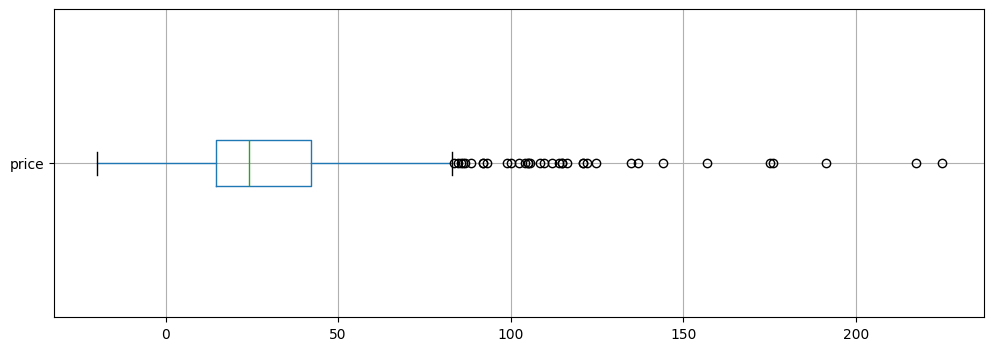

In [40]:
#Création d'une boîte à moustache de la répartition des prix grâce à Pandas

# vert=False permet de l'afficher à l'horizontale
# figsize agrandit un peu l'image pour la lisibilité
df_final.boxplot(column='price', vert=False, figsize=(12, 4))


In [41]:
#Autre méthode avec plotly express

# points='outliers' permet d'afficher explicitement les points qui sortent du lot
fig = px.box(df_final, x="price", title="Répartition des prix (Boxplot)", points="outliers")
fig.show()


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utilisation de méthodes statistiques</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [42]:
#Calculer la moyenne du prix

moyenne = df_final['price'].mean()
print(f"Moyenne des prix : {moyenne:.2f} €")

#Calculer l'écart-type du prix

ecart_type = df_final['price'].std()
print(f"Ecart-type des prix : {ecart_type:.2f} €")

#Calculer le Z-score

# La formule est : (Prix - Moyenne) / Ecart-type
df_final['z_score'] = (df_final['price'] - moyenne) / ecart_type


# Test aperçu pour voir si le calcul a fonctionné


display(df_final[['price', 'z_score']].head())


Moyenne des prix : 32.19 €
Ecart-type des prix : 26.71 €


,price,z_score
0,8.6,-0.883035
1,41.0,0.329900
2,39.0,0.255027
3,59.9,1.037445
4,22.5,-0.362671


In [43]:
#Quel est le seuil prix dont le z-score est supérieur à 3?


# Seuil = Moyenne + (3 * Ecart-type) (80-85€)

seuil_z3 = moyenne + (3 * ecart_type)

print(f"Le seuil de prix pour un Z-score > 3 est de : {seuil_z3:.2f} €")


Le seuil de prix pour un Z-score > 3 est de : 112.32 €


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'intervalle interquartile</h3>
</div>

In [44]:
#Utilisation de la fonction "describe" de Pandas pour l'étude des mesures de dispersion

# Cela nous donne Q1 (25%) et Q3 (75%)
print(df_final['price'].describe())


count    825.000000
mean      32.187697
std       26.712077
min      -20.000000
25%       14.500000
50%       24.300000
75%       42.000000
max      225.000000
Name: price, dtype: float64


In [45]:
#Définir un seuil pour les articles "outliers" en prix

# Calcul de l'intervalle interquartile (IQR)
Q1 = df_final['price'].quantile(0.25)
Q3 = df_final['price'].quantile(0.75)
IQR = Q3 - Q1


# Calcul du seuil (La formule standard est Q3 + 1.5 * IQR)
seuil_prix = Q3 + (1.5 * IQR)

print(f"Premier Quartile (Q1) : {Q1} €")
print(f"Troisième Quartile (Q3) : {Q3} €")
print(f"IQR : {IQR}")
print(f"Seuil de prix pour être considéré comme outlier (IQR) : {seuil_prix} €")

Premier Quartile (Q1) : 14.5 €
Troisième Quartile (Q3) : 42.0 €
IQR : 27.5
Seuil de prix pour être considéré comme outlier (IQR) : 83.25 €


In [46]:
#Définir le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"

# On isole les outliers dans un dataframe dédié
df_outliers = df_final[df_final['price'] > seuil_prix]

# Nombre d'articles
nombre_outliers = len(df_outliers)

# Proportion (en %)
proportion = (nombre_outliers / len(df_final)) * 100

print(f"Nombre d'articles outliers : {nombre_outliers}")
print(f"Proportion des articles outliers : {proportion:.2f} %")


Nombre d'articles outliers : 36
Proportion des articles outliers : 4.36 %


In [47]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?


# On affiche les noms des produits considérés comme outliers, triés par prix décroissant
# Cela permet de vérifier s'il s'agit d'erreurs de saisie ou de produits de luxe.
print("--- Liste des produits outliers (Top 10) ---")
display(df_outliers[['product_id', 'post_title', 'price']].sort_values(by='price', ascending=False).head(10))


# En affichant la liste des produits concernés (post_title), je constate qu'il s'agit de Champagnes, de Cognacs ou de grands vins millésimés (ex: "Champagne Gosset Célébris", "Cognac Frapin"). Donc pas d'erreur de prix mais produits de luxe uniquement (gamme luxe), à conserve pour analyse du CA

--- Liste des produits outliers (Top 10) ---


,product_id,post_title,price
567,4352,Champagne Egly-Ouriet Grand Cru Millésimé 2008,225.0
204,5001,David Duband Charmes-Chambertin Grand Cru 2014,217.5
269,5892,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,191.3
24,4402,Cognac Frapin VIP XO,176.0
313,5767,Camille Giroud Clos de Vougeot 2016,175.0
33,4406,Cognac Frapin Château de Fontpinot 1989 20 Ans...,157.0
745,4594,NaN,144.0
171,4904,Domaine Des Croix Corton Charlemagne Grand Cru...,137.0
257,6126,Champagne Gosset Célébris Vintage 2007,135.0
256,5612,Domaine Weinbach Gewurztraminer Grand Cru Furs...,124.8


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univariée du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivariée  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [48]:
##############################
# Calculer le CA du site web #
##############################

#Créer une colonne calculant le CA par article

# Prix unitaire * Quantité vendue
df_final['ca_par_article'] = df_final['price'] * df_final['total_sales']

#Calculer la somme de la colonne "ca_par_article"

ca_total_web = df_final['ca_par_article'].sum()

#Ce résultat correspond au chiffre d'affaire du site web

print(f"Chiffre d'affaires total du site web : {ca_total_web:.2f} €")


# Test aperçu pour voir si le calcul a fonctionné (70 568 €)


display(df_final[['product_id', 'post_title', 'price', 'total_sales', 'ca_par_article']].sort_values(by='ca_par_article', ascending=False).head())




Chiffre d'affaires total du site web : 143680.10 €


,product_id,post_title,price,total_sales,ca_par_article
567,4352,Champagne Egly-Ouriet Grand Cru Millésimé 2008,225.0,11.0,2475.0
269,5892,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,191.3,6.0,1147.8
77,4353,Champagne Egly-Ouriet Grand Cru Brut Rosé,79.5,14.0,1113.0
349,5826,Agnès Levet Côte Rôtie Améthyste 2017,41.2,20.0,824.0
157,6212,Domaine des Comtes Lafon Volnay 1er Cru Santen...,115.0,7.0,805.0


In [49]:
###############################
# Palmarès des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge

# On utilise df_final car c'est là qu'on a calculé 'ca_par_article'
df_final = df_final.sort_values(by='ca_par_article', ascending=False)

#Réinitialiser l'index du dataset par un reset_index
# drop=True permet de ne pas garder l'ancien index comme une colonne

df_final = df_final.reset_index(drop=True)


#Afficher les 20 premiers articles en CA

print("--- Top 20 des produits par Chiffre d'Affaires ---")
display(df_final[['product_id', 'post_title', 'ca_par_article']].head(20))


#Graphique en barre des 20 premiers articles avec plotly express (Champagne Gosset en tete)


fig = px.bar(df_final.head(20),
             x='post_title',
             y='ca_par_article',
             title="Top 20 des produits par Chiffre d'Affaires",
             labels={'post_title': 'Nom du produit', 'ca_par_article': "Chiffre d'Affaires (€)"},
             text_auto='.2s') # Affiche la valeur sur la barre de façon lisible

# Pour l'esthétique : on pivote les noms de produits pour qu'ils soient lisibles
fig.update_layout(xaxis_tickangle=-45)

fig.show()


--- Top 20 des produits par Chiffre d'Affaires ---


,product_id,post_title,ca_par_article
0,4352,Champagne Egly-Ouriet Grand Cru Millésimé 2008,2475.0
1,5892,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,1147.8
2,4353,Champagne Egly-Ouriet Grand Cru Brut Rosé,1113.0
3,5826,Agnès Levet Côte Rôtie Améthyste 2017,824.0
4,6212,Domaine des Comtes Lafon Volnay 1er Cru Santen...,805.0
5,5026,Champagne Agrapart &amp; Fils Minéral Extra Br...,781.2
6,5008,Domaine des Comtes Lafon Volnay 1er Cru Santen...,735.0
7,5767,Camille Giroud Clos de Vougeot 2016,700.0
8,6126,Champagne Gosset Célébris Vintage 2007,675.0
9,5025,Champagne Agrapart &amp; Fils L'Avizoise Extra...,672.0


In [50]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part du CA de la ligne dans le dataset

# (CA du produit / CA Total) * 100
ca_total = df_final['ca_par_article'].sum()
df_final['part_du_ca'] = (df_final['ca_par_article'] / ca_total) * 100

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée

# La fonction .cumsum() additionne la ligne actuelle avec toutes les précédentes
# (Le dataframe doit être trié par CA décroissant pour que ça marche, ce qu'on a fait juste avant)
df_final['ca_cumul'] = df_final['part_du_ca'].cumsum()

#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA

# On filtre pour ne garder que les lignes tant que le cumul est inférieur ou égal à 80%
articles_top_80 = df_final[df_final['ca_cumul'] <= 80]
nombre_articles_80 = len(articles_top_80)

print(f"Nombre d'articles générant 80% du CA : {nombre_articles_80}")

#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web

total_articles = len(df_final)
proportion = (nombre_articles_80 / total_articles) * 100

print(f"Ces {nombre_articles_80} articles représentent {proportion:.2f}% du catalogue total.")

# Petit affichage pour vérifier le cumul
display(df_final[['post_title', 'ca_par_article', 'part_du_ca', 'ca_cumul']].head())


Nombre d'articles générant 80% du CA : 434
Ces 434 articles représentent 52.61% du catalogue total.


,post_title,ca_par_article,part_du_ca,ca_cumul
0,Champagne Egly-Ouriet Grand Cru Millésimé 2008,2475.0,1.722577,1.722577
1,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,1147.8,0.798858,2.521435
2,Champagne Egly-Ouriet Grand Cru Brut Rosé,1113.0,0.774638,3.296072
3,Agnès Levet Côte Rôtie Améthyste 2017,824.0,0.573496,3.869569
4,Domaine des Comtes Lafon Volnay 1er Cru Santen...,805.0,0.560272,4.429841


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en quantité</h3>
</div>

In [51]:
#####################################
# Palmarès des articles en quantité #
#####################################

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge

# On utilise la colonne 'total_sales' de df_final
df_final = df_final.sort_values(by='total_sales', ascending=False)

#Réinitialiser l'index du dataset par un reset_index

df_final = df_final.reset_index(drop=True)

#Afficher les 20 premiers articles en quantité

print("--- Top 20 des produits par Quantité Vendue ---")
display(df_final[['product_id', 'post_title', 'total_sales']].head(20))

#Graphique en barre des 20 premiers articles avec plotly express (Quanité vin et pas champagne logique prix moins cher)

fig = px.bar(df_final.head(20),
             x='post_title',
             y='total_sales',
             title="Top 20 des meilleures ventes (en volume)",
             labels={'post_title': 'Nom du produit', 'total_sales': 'Nombre de ventes'},
             text_auto=True) # Affiche le chiffre exact sur la barre


             # Pour la lisibilité des noms en bas
fig.update_layout(xaxis_tickangle=-45)

fig.show()


--- Top 20 des produits par Quantité Vendue ---


,product_id,post_title,total_sales
0,4867,Château De La Selve IGP Coteaux de l'Ardèche M...,36.0
1,4203,Mas Laval IGP Pays d'Hérault Les Pampres Blanc...,27.0
2,4275,I Fabbri Chianti Classico Lamole 2017,24.0
3,4726,François Baur Pinot Noir Schlittweg 2017,22.0
4,4647,Bernard Baudry Chinon Rouge La Croix Boissée 2017,22.0
5,6129,Moulin de Gassac IGP Pays d'Hérault Guilhem Bl...,20.0
6,5826,Agnès Levet Côte Rôtie Améthyste 2017,20.0
7,4220,Xavier Frissant Touraine Amboise Chenin Les Pi...,18.0
8,5803,Château Tour Haut-Caussan Médoc 2015,17.0
9,6569,Decelle-Villa Chorey-Lès-Beaune 2016,17.0


In [52]:
#############################
# Calculer le 20 / 80 en CA #
#############################

# S'assurer que le dataframe est bien trié par quantité décroissante (normalement fait à l'étape précédente)
df_final = df_final.sort_values(by='total_sales', ascending=False)

#Créer une colonne calculant la part en quantité de la ligne dans le dataset

#  (Ventes du produit / Ventes Totales) * 100
total_ventes_volume = df_final['total_sales'].sum()
df_final['part_quantite'] = (df_final['total_sales'] / total_ventes_volume) * 100

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée

df_final['quantite_cumul'] = df_final['part_quantite'].cumsum()

#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité

# On garde les lignes tant qu'on n'a pas dépassé les 80% du volume total
articles_top_80_qt = df_final[df_final['quantite_cumul'] <= 80]
nombre_articles_80_qt = len(articles_top_80_qt)

print(f"Nombre d'articles générant 80% des ventes en volume : {nombre_articles_80_qt}")

#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web

proportion_qt = (nombre_articles_80_qt / len(df_final)) * 100

print(f"Ces {nombre_articles_80_qt} articles représentent {proportion_qt:.2f}% du catalogue total.")

# Aperçu pour vérification
display(df_final[['post_title', 'total_sales', 'part_quantite', 'quantite_cumul']].head())


Nombre d'articles générant 80% des ventes en volume : 433
Ces 433 articles représentent 52.48% du catalogue total.


,post_title,total_sales,part_quantite,quantite_cumul
0,Château De La Selve IGP Coteaux de l'Ardèche M...,36.0,0.625978,0.625978
1,Mas Laval IGP Pays d'Hérault Les Pampres Blanc...,27.0,0.469484,1.095462
2,I Fabbri Chianti Classico Lamole 2017,24.0,0.417319,1.512780
4,Bernard Baudry Chinon Rouge La Croix Boissée 2017,22.0,0.382542,1.895323
3,François Baur Pinot Noir Schlittweg 2017,22.0,0.382542,2.277865


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

In [53]:
######################################
# Calculer le nombre de mois de stock #
######################################

#Import de numpy

import numpy as np

#Création de la colonne Rotation de stock

# Stock actuel / Ventes mensuelles moyennes
# On suppose que 'total_sales' représente les ventes sur une année (donc on divise par 12)
# Si total_sales = 0, cela va créer une division par zéro -> infini (inf)
df_final['months_stock'] = df_final['stock_quantity'] / (df_final['total_sales'] / 12)

#Remplacement des "inf" par 0

# (Ce sont les produits qui ont du stock mais 0 vente. Mathématiquement c'est infini,mais on les met à 0 pour pouvoir afficher le graphique sans erreur)
df_final['months_stock'] = df_final['months_stock'].replace([np.inf, -np.inf], 0)

# On remplace aussi les NaN (Not a Number) par 0 au cas où (0/0)
df_final['months_stock'] = df_final['months_stock'].fillna(0)

#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge

df_final = df_final.sort_values(by='months_stock', ascending=False)

#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock

print("--- Flop 20 : Les produits avec le plus de couverture de stock ---")

# On prend les 20 premiers (qui ont maintenant les plus grosses valeurs grâce au tri)
flop_20_stock = df_final.head(20)

fig = px.bar(flop_20_stock,
             x='post_title',
             y='months_stock',
             title="Top 20 des produits avec le plus fort stock dormant (en mois)",
             labels={'post_title': 'Produit', 'months_stock': 'Mois de stock théoriques'},
             text_auto='.1f')

fig.update_layout(xaxis_tickangle=-45)
fig.show()

--- Flop 20 : Les produits avec le plus de couverture de stock ---


In [54]:
####################################
# Valorisation des stocks en euros #
####################################

#Création de la colonne Valorisation des stocks en euros

# Prix unitaire * Quantité en stock
df_final['Valorisation_stock_euros'] = df_final['price'] * df_final['stock_quantity']

#Calculer la somme de la colonne "Valorisation_stock_euros"

valeur_totale_stock = df_final['Valorisation_stock_euros'].sum()

print(f"Valeur totale du stock actuel : {valeur_totale_stock:,.2f} €")

Valeur totale du stock actuel : 531,628.80 €


In [55]:
##############################################
# Valorisation du nombre de produits en stock #
##############################################

#Calculer la somme de la colonne stock quantity (20 0000 ou 21 0000)

volume_total_stock = df_final['stock_quantity'].sum()

print(f"Nombre total de bouteilles en stock : {volume_total_stock}")

Nombre total de bouteilles en stock : 17811


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [56]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne Prix HT

# Formule : Prix TTC / (1 + Taux TVA)
# TVA à 20% (donc on divise par 1.2)
df_final['price_ht'] = df_final['price'] / 1.2

#Création de la colonne Taux de marge

# ((Prix de vente HT - Prix d'achat) / Prix d'achat) * 100
# Cela nous donne la marge en pourcentage par rapport au coût d'achat
df_final['taux_marge'] = ((df_final['price_ht'] - df_final['purchase_price']) / df_final['purchase_price']) * 100

#Afficher le prix minimum de la colonne "taux_marge"

print(f"Taux de marge minimum : {df_final['taux_marge'].min():.2f} %")

#Afficher le prix maximum de la colonne "taux_marge"

print(f"Taux de marge maximum : {df_final['taux_marge'].max():.2f} %")


# Petit aperçu pour vérifier
display(df_final[['post_title', 'price', 'price_ht', 'purchase_price', 'taux_marge']].head())

Taux de marge minimum : -264.50 %
Taux de marge maximum : 91.41 %


,post_title,price,price_ht,purchase_price,taux_marge
612,Champagne Gosset Grand Millésime 2006,53.0,44.166667,32.15,37.376879
521,Champagne Gosset Célébris Vintage 2007,135.0,112.500000,80.33,40.047305
626,Champagne Egly-Ouriet Premier Cru Les Vignes d...,51.6,43.000000,31.00,38.709677
544,Champagne Egly-Ouriet Grand Cru Brut Tradition,59.0,49.166667,34.76,41.446107
656,Champagne Mailly Grand Cru Brut Rosé,37.5,31.250000,21.88,42.824497


In [57]:
#Affichage de la ligne avec un taux de marge inférieur à 0

ventes_a_perte = df_final[df_final['taux_marge'] < 0]

if len(ventes_a_perte) > 0:
    print(f" Alerte : {len(ventes_a_perte)} produit(s) vendu(s) à perte !")
    display(ventes_a_perte[['product_id', 'post_title', 'price', 'purchase_price', 'taux_marge']])
else:
    print("Aucune vente à perte détectée.")


 Alerte : 7 produit(s) vendu(s) à perte !


,product_id,post_title,price,purchase_price,taux_marge
739,4233,NaN,-20.00,10.33,-261.342369
772,6594,NaN,-9.10,4.61,-264.497469
760,5017,NaN,-8.00,4.34,-253.609831
701,4355,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,12.65,77.48,-86.394338
726,4864,NaN,8.30,9.99,-30.764097
770,6324,NaN,92.00,99.00,-22.558923
820,7196,NaN,31.00,31.20,-17.200855


In [58]:
#Création d'un dataframe avec le taux de marge moyen par type de produit

# On regroupe par 'post_type' (qui ne contient que 'product' normalement)
df_marge_moyenne = df_final.groupby('post_type')['taux_marge'].mean().reset_index()

print("Marge moyenne par type :")
display(df_marge_moyenne)

#Affichage dans un graphique du taux de marge par type de produit

fig = px.bar(df_marge_moyenne,
             x='post_type',
             y='taux_marge',
             title="Taux de marge moyen par type de produit",
             labels={'taux_marge': 'Taux de marge moyen (%)', 'post_type': 'Type de produit'},
             text_auto='.1f',
             color='post_type')

fig.show()


Marge moyenne par type :


,post_type,taux_marge
0,product,61.017018


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des corrélations entre les variables stock, sales et price</h3>
</div>

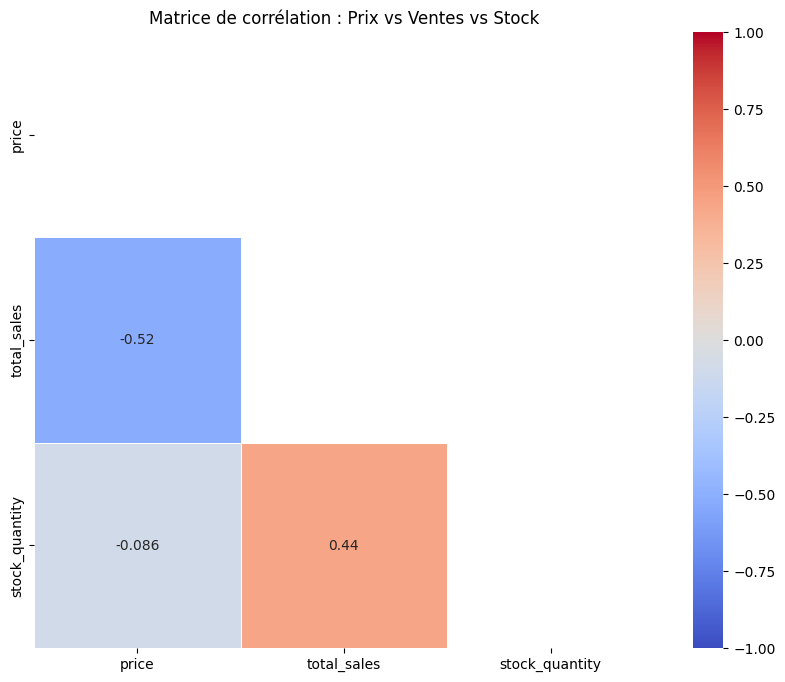

In [59]:
############################
# Analyse des corrélations #
############################

#Importation de Seaborn

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


#Création d'une heatmap de corrélation avec les variables stock, sales et price

# On sélectionne uniquement les colonnes numériques qui nous intéressent
# sales = total_sales, stock = stock_quantity
sub_df = df_final[['price', 'total_sales', 'stock_quantity']]

# Calcul de la matrice de corrélation

corr_matrix = sub_df.corr()


# 3. Création du mask pour n'afficher qu'une demi heatmap (triangle inférieur)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. Affichage du graphique
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,        # Affiche les chiffres dans les cases
            cmap='coolwarm',   # Code couleur (Rouge = fort, Bleu = faible/négatif)
            vmin=-1, vmax=1,   # Borne l'échelle entre -1 et 1
            center=0,
            linewidths=0.5)

plt.title("Matrice de corrélation : Prix vs Ventes vs Stock")
plt.show()

In [60]:
#Que peut-on conclure des corrélations ?

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mise à disposition de la nouvelle table sur un fichier Excel</h3>
</div>

In [61]:
#Mettre le dataset df_merge sur un fichier Excel

# index=False permet d'évite d'avoir une colonne de numérotation inutile dans le fichier Excel
df_final.to_excel('analyse_bottleneck_finale.xlsx', index=False)

print("Fichier Excel généré avec succès !")


Fichier Excel généré avec succès !
